In [77]:
import sys
sys.path.append('../simulation')
from noise_models import pink_noise, white_noise, lorentzian_noise, total_noise

In [78]:
import matplotlib.pyplot as plt
import numpy as np


In [79]:
omega = np.linspace(0, 10e6, 10000)
A_pink = 1e9
alpha = 1.0
A_white = 1e3
A_lorentzian = 5e5
f0 = 5e6
gamma = 5e4

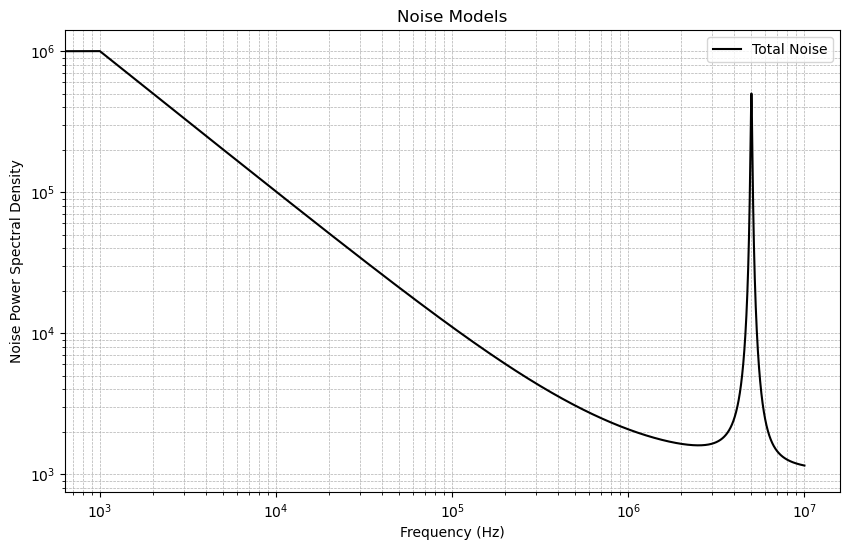

In [80]:
plt.figure(figsize=(10, 6))
#plt.plot(omega, pink_noise(omega, A_pink, alpha), label='Pink Noise', linestyle='--')
#plt.plot(omega, white_noise(omega, A_white), label='White Noise', linestyle='--')
#plt.plot(omega, lorentzian_noise(omega, A_lorentzian, f0, gamma), label='Lorentzian Noise', linestyle='--')
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), label='Total Noise', color='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Noise Power Spectral Density')
plt.title('Noise Models')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


In [81]:
import sys
sys.path.append('../simulation')
from filter_functions import F_Ramsey, F_Hahn, F_CPMG, F_XY8, F_UDD

In [82]:
t = np.linspace(1e-6, 500e-6, 100)
omega_MHz = omega / (2 * np.pi * 1e6)

In [83]:
import sys
sys.path.append('../simulation')
from chi_computation import compute_chi

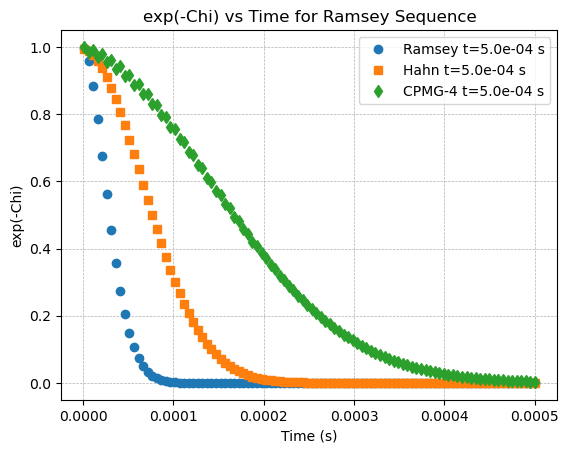

In [90]:
chi_Ramsey = []
for i in range(len(t)):
    F_Ramsey_values = F_Ramsey(omega, t[i])
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_Ramsey_values)
    chi_Ramsey.append(chi)

chi_Hahn = []
for i in range(len(t)):
    F_Hahn_values = F_Hahn(omega, t[i])
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_Hahn_values)
    chi_Hahn.append(chi)

chi_CPMG4 = []
for i in range(len(t)):
    F_CPMG_values = F_CPMG(omega, t[i], 4)
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_CPMG_values)
    chi_CPMG4.append(chi)


plt.plot(t, np.exp(-np.array(chi_Ramsey)), 'o', label=f'Ramsey t={t[i]:.1e} s')
plt.plot(t, np.exp(-np.array(chi_Hahn)), 's', label=f'Hahn t={t[i]:.1e} s')
plt.plot(t, np.exp(-np.array(chi_CPMG4)), 'd', label=f'CPMG-4 t={t[i]:.1e} s')
plt.xlabel('Time (s)')
plt.ylabel('exp(-Chi)')
plt.title('exp(-Chi) vs Time for Ramsey Sequence')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


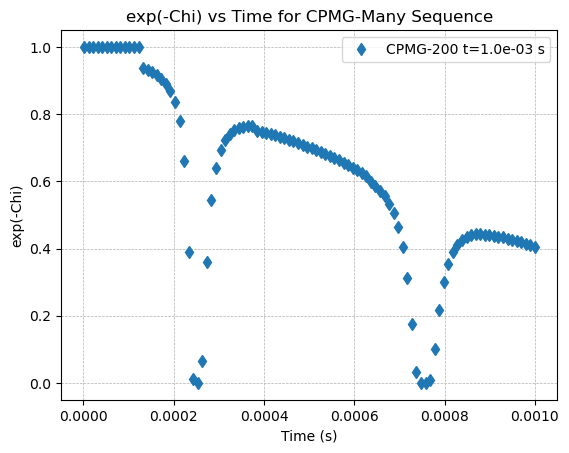

In [94]:
t_long = np.linspace(1e-6, 1000e-6, 100)
chi_CPMG200 = []
for i in range(len(t_long)):
    F_CPMG_values = F_CPMG(omega, t_long[i], 200)
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_CPMG_values)
    chi_CPMG200.append(chi)

plt.plot(t_long, np.exp(-np.array(chi_CPMG200)), 'd', label=f'CPMG-200 t={t_long[i]:.1e} s')
plt.xlabel('Time (s)')
plt.ylabel('exp(-Chi)')
plt.title('exp(-Chi) vs Time for CPMG-Many Sequence')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
